## LOGISTIC REGRESSION — Diabetes Prediction Assignment

### Background
This notebook works with the **Pima Indians Diabetes dataset** (`diabetes.csv`), which contains diagnostic health measurements for female patients, along with an `Outcome` column (1 = diabetic, 0 = not diabetic). The goal is to build a Logistic Regression model that predicts diabetes risk from these measurements, evaluate it thoroughly, interpret its coefficients, and deploy it with Streamlit.

### 1. Data Exploration

In [1]:
# 1a. Load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")
df.head()

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

In [2]:
# 1b. Examine features, types, and summary statistics
print(df.shape)
df.info()
df.describe()

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


All 9 columns are numeric — there are no categorical variables in this dataset. `Outcome` is the binary target (1 = diabetic, 0 = not). However, several columns (`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`) contain **0 values that are not physiologically possible** — these are almost certainly missing readings encoded as 0, and will be handled in preprocessing.

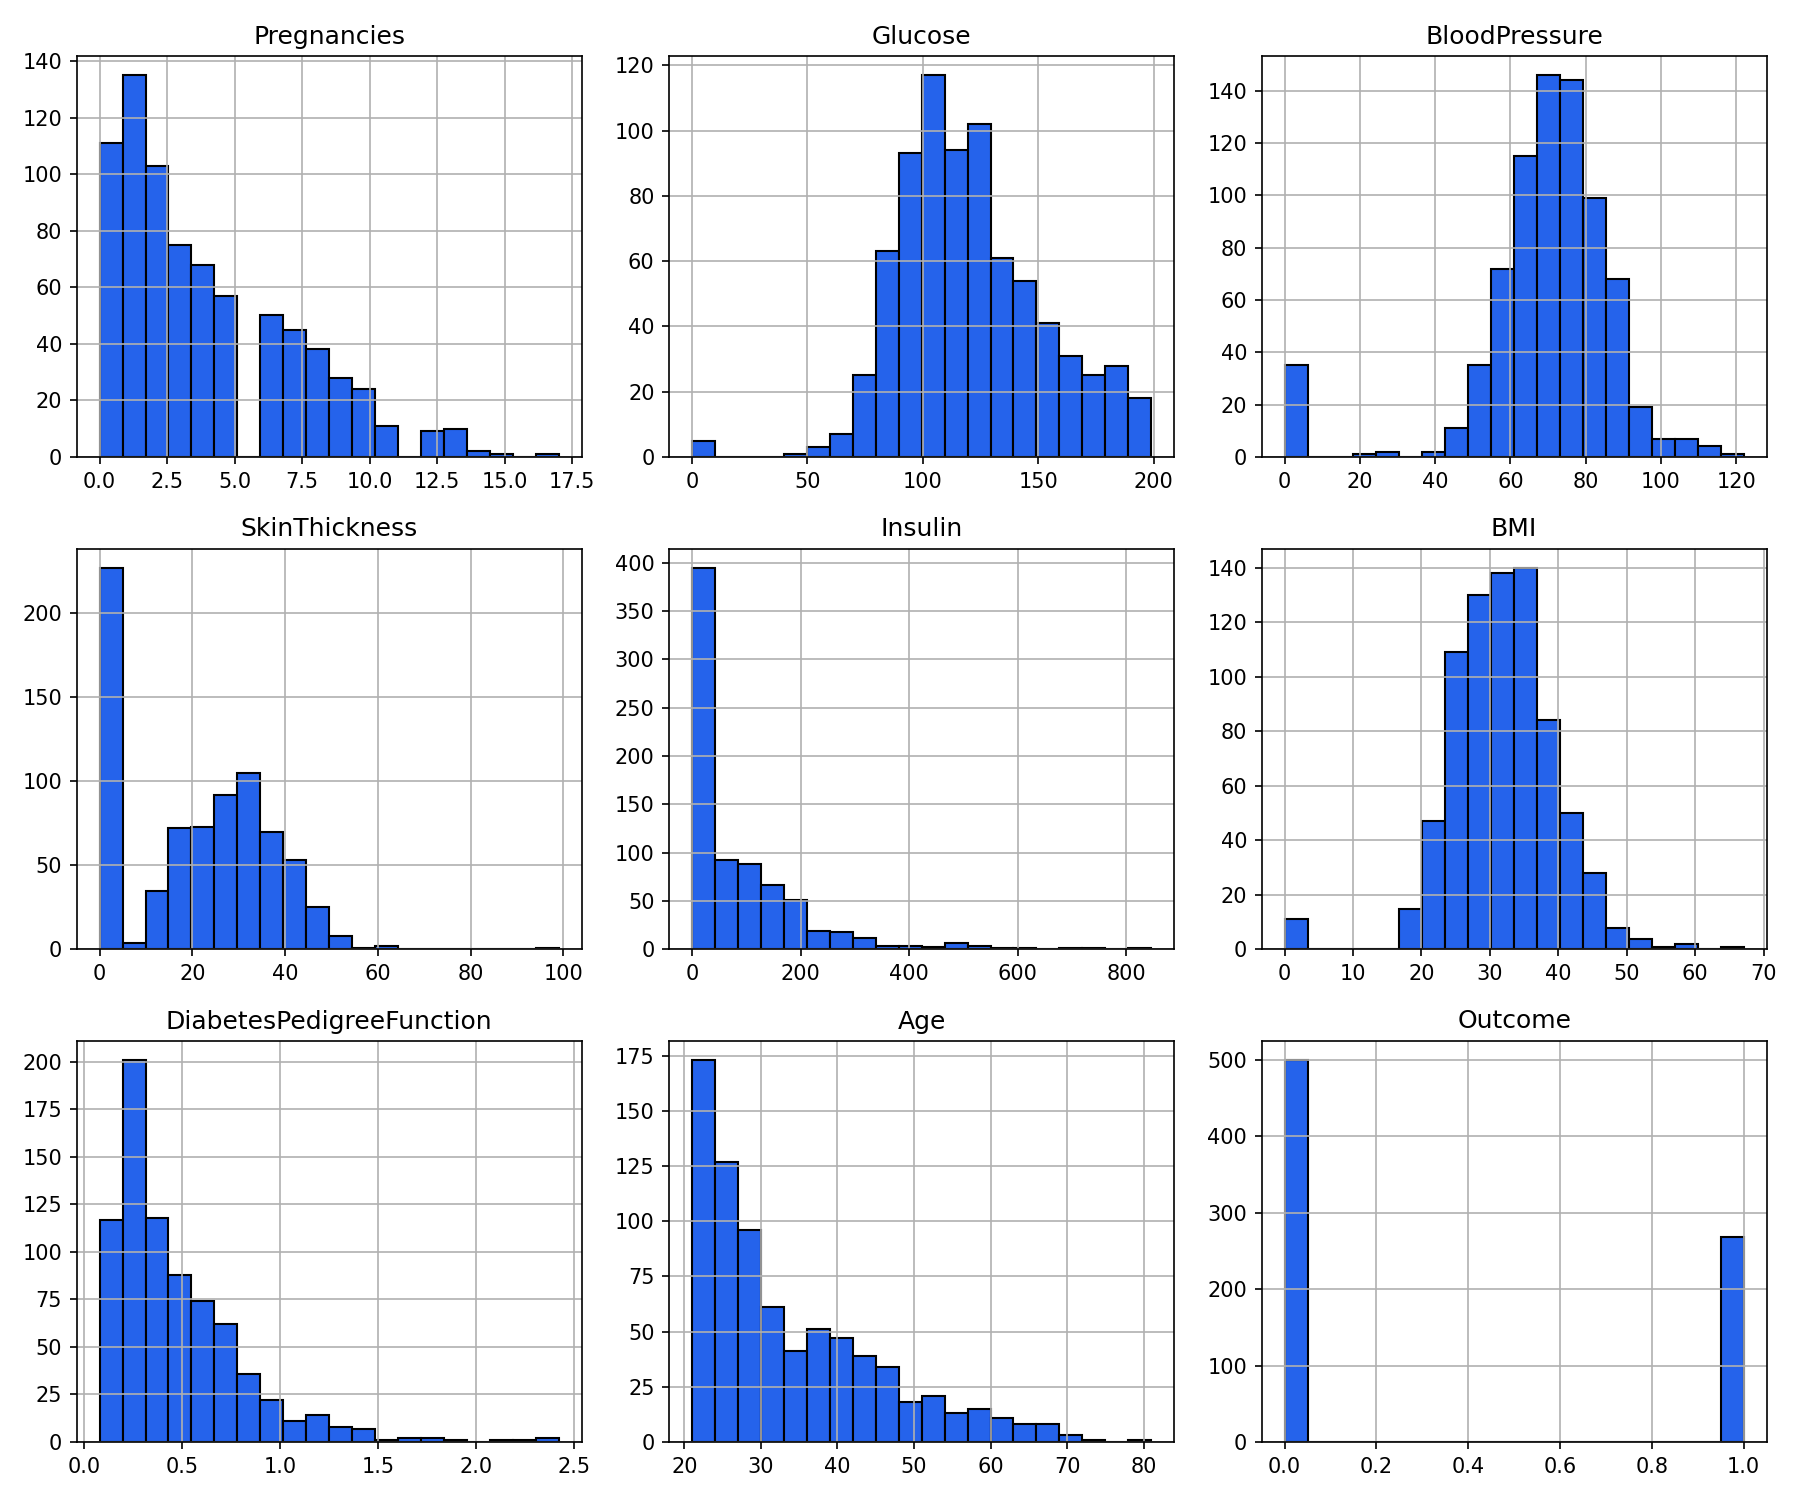

In [3]:
# 1c. Visualize distributions — histograms
df.hist(figsize=(12, 10), bins=20, color='#2563eb', edgecolor='black')
plt.tight_layout()
plt.show()

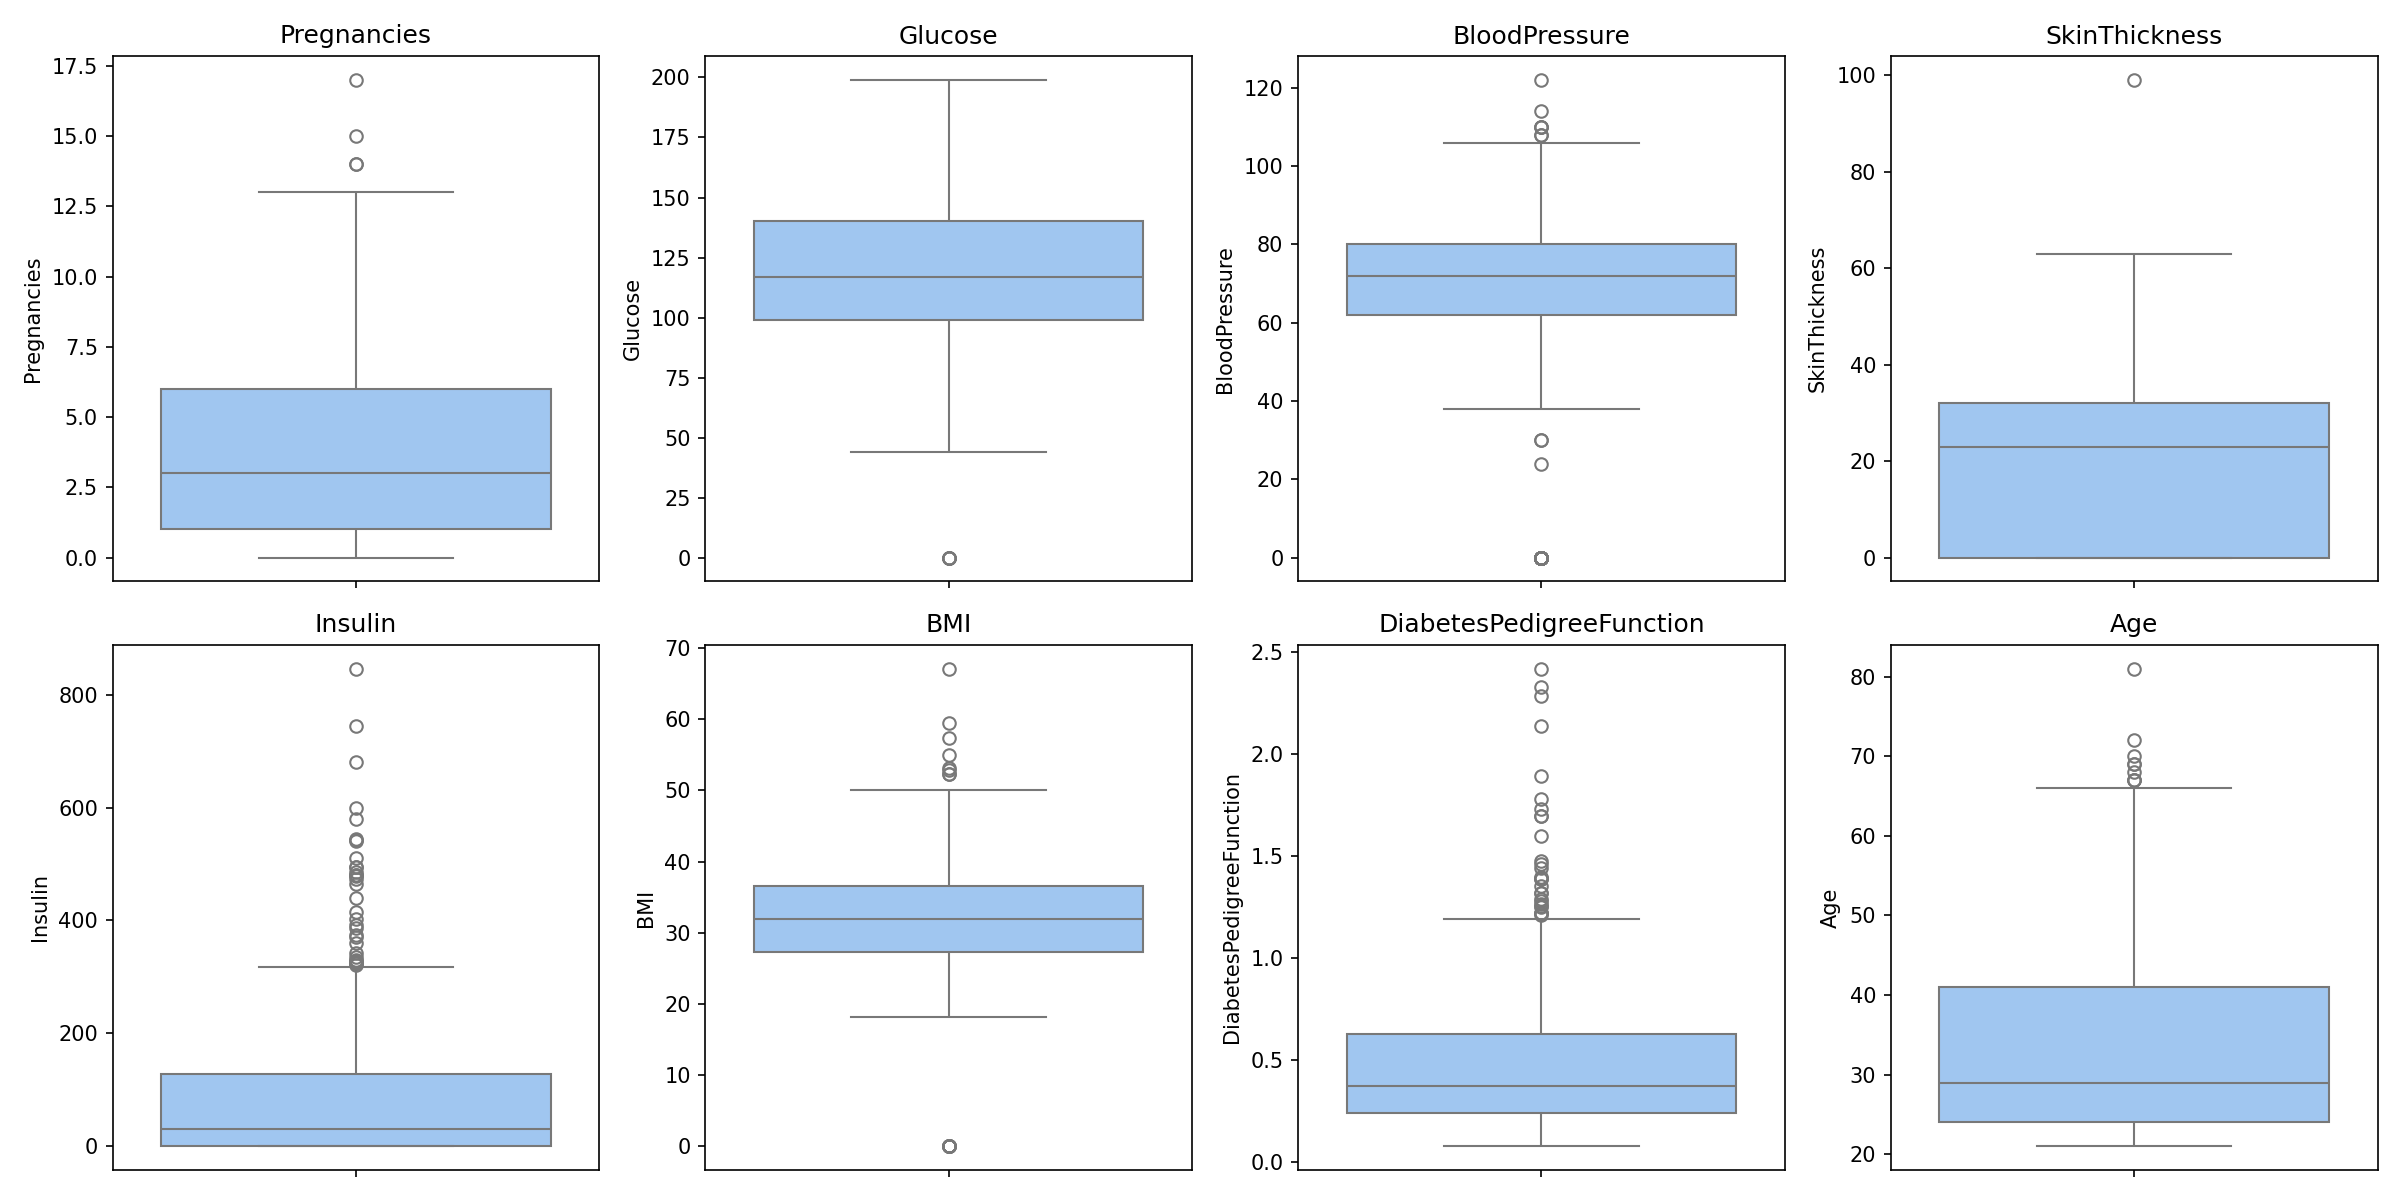

In [4]:
# Boxplots to spot outliers and the suspicious zero values
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cols = df.columns[:-1]
for ax, col in zip(axes.flatten(), cols):
    sns.boxplot(y=df[col], ax=ax, color='#93c5fd')
    ax.set_title(col)
plt.tight_layout()
plt.show()

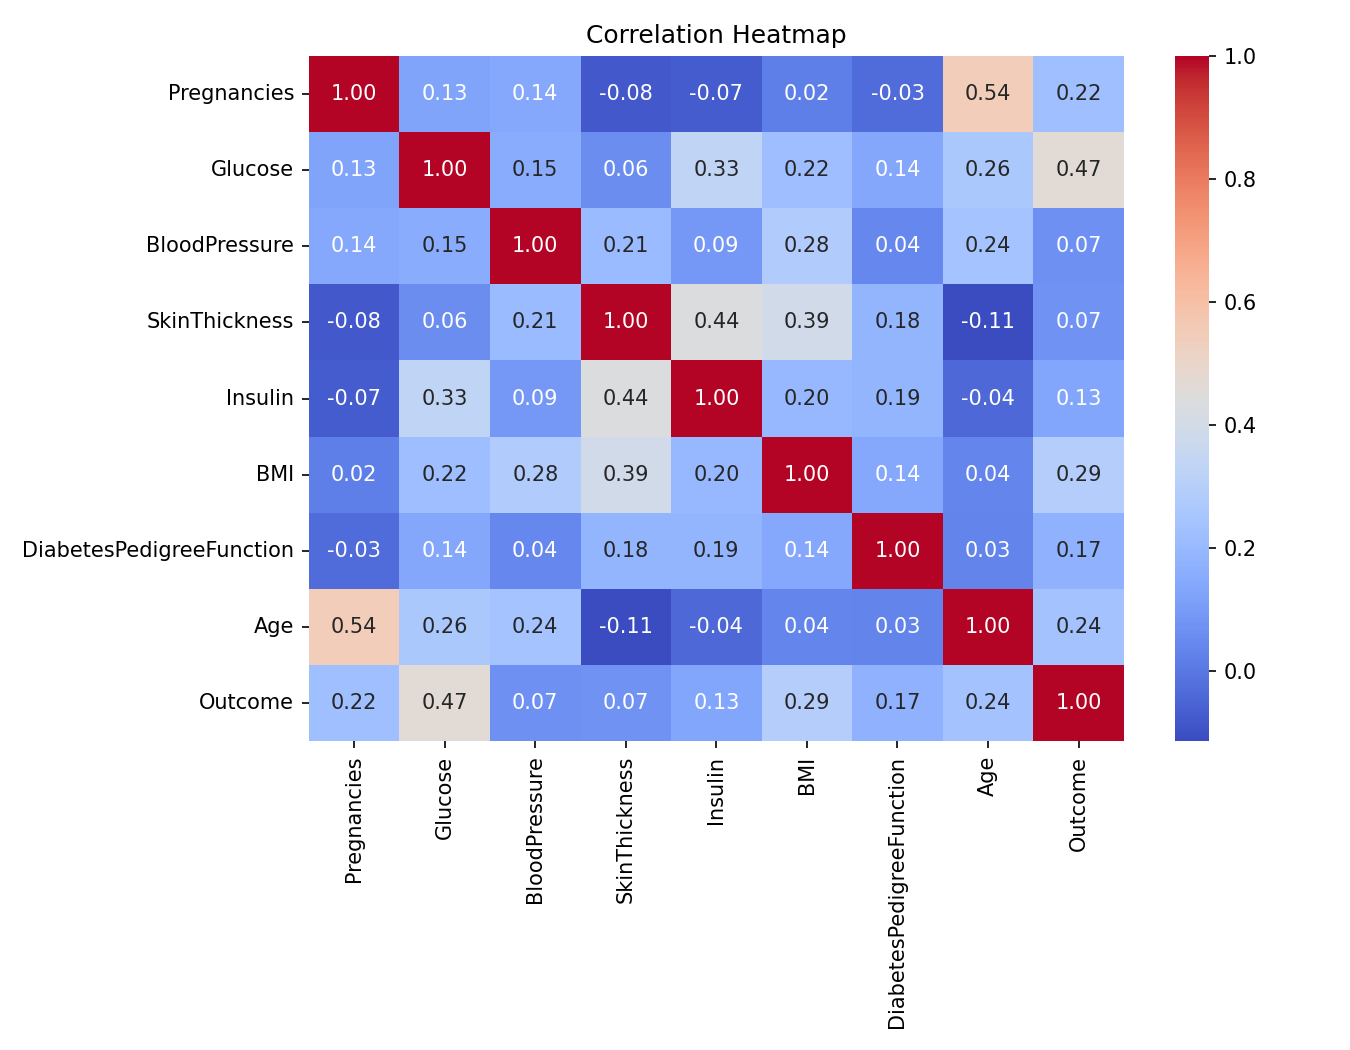

In [5]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observed patterns:**
- `Glucose` shows the strongest positive correlation with `Outcome`, consistent with it being the primary clinical marker for diabetes.
- `BMI`, `Age`, and `Pregnancies` also correlate positively with `Outcome`, though more weakly.
- `SkinThickness` and `Insulin` are fairly strongly correlated with each other (~0.44), and both have a large number of 0 values, which biases the raw correlation numbers until those are treated as missing.
- Boxplots confirm right-skewed distributions for `Insulin` and `DiabetesPedigreeFunction`, and clusters of implausible 0 values for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`.

### 2. Data Preprocessing

In [6]:
# 2a. Handle missing values
# Glucose, BloodPressure, SkinThickness, Insulin, and BMI cannot legitimately be 0
# in a living patient, so these are treated as missing and imputed with the median.
cols_with_zero_as_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
for col in cols_with_zero_as_missing:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print('Missing values introduced:')
print(df_clean[cols_with_zero_as_missing].isnull().sum())

for col in cols_with_zero_as_missing:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print('\nMissing values after median imputation:', df_clean.isnull().sum().sum())

Missing values introduced:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after median imputation: 0


**2b. Encode categorical variables:** this dataset contains no categorical/text columns — every feature is already numeric, so no encoding step (e.g. one-hot or label encoding) is required here.

### 3. Model Building

In [7]:
# 3a/3b. Build and train a Logistic Regression model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

FEATURE_NAMES = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                  'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df_clean[FEATURE_NAMES]
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)
print('Model trained on', X_train.shape[0], 'samples with', X_train.shape[1], 'features.')

Model trained on 614 samples with 8 features.


### 4. Model Evaluation

In [8]:
# 4a. Evaluate on the test set
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-score : {f1:.4f}')
print(f'ROC-AUC  : {auc:.4f}')
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))

Accuracy : 0.7078
Precision: 0.6000
Recall   : 0.5000
F1-score : 0.5455
ROC-AUC  : 0.8130

Confusion Matrix:
 [[82 18]
 [27 27]]


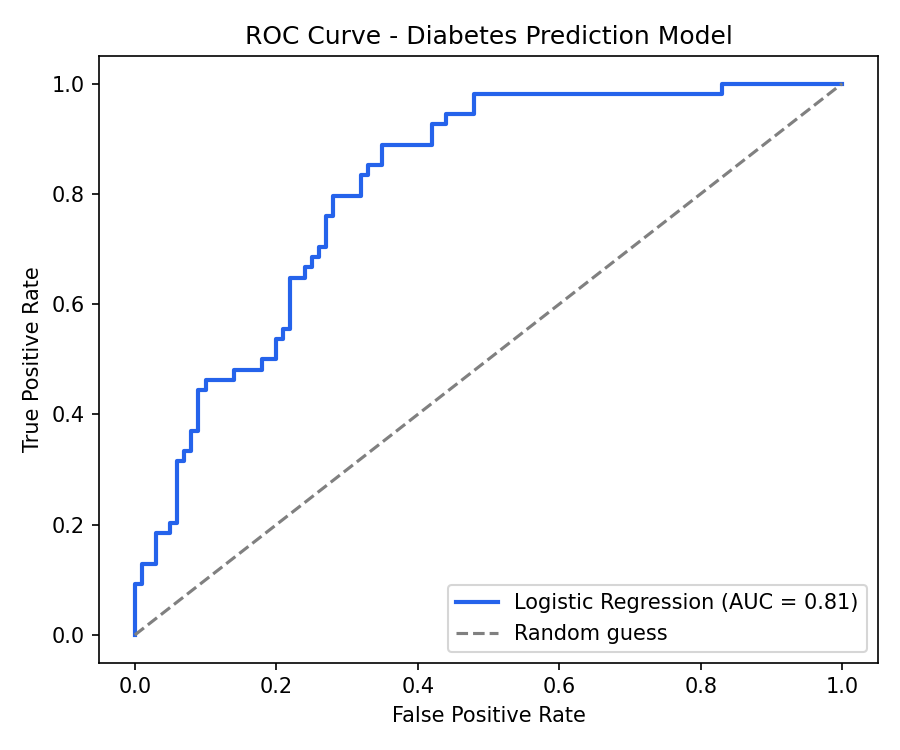

In [9]:
# Visualize the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})', color='#2563eb', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Diabetes Prediction Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Evaluation summary:** the model reaches **70.8% accuracy** and, more importantly for a screening tool, a strong **ROC-AUC of 0.81**, meaning it separates diabetic from non-diabetic patients well across thresholds. Recall (50%) is lower than precision (60%), meaning the model still misses a meaningful share of true diabetic cases at the default 0.5 threshold — in a medical screening context, this threshold could be lowered to prioritize recall (catching more true positives) at the cost of more false alarms.

### 5. Interpretation

In [10]:
# 5a. Interpret the coefficients
coef_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'Coefficient': pipeline.named_steps['clf'].coef_[0]
}).sort_values('Coefficient', ascending=False)
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])
coef_df

                    Feature  Coefficient  Odds_Ratio
1                   Glucose     1.182511    3.262464
5                       BMI     0.688735    1.991324
0               Pregnancies     0.377502    1.458703
6  DiabetesPedigreeFunction     0.233386    1.262964
7                       Age     0.147798    1.159295
3             SkinThickness     0.028225    1.028625
2             BloodPressure    -0.044066    0.956891
4                   Insulin    -0.066157    0.935993

**Interpretation:** because all features were standardized before fitting, coefficients are directly comparable in magnitude.

- **Glucose** has by far the largest positive coefficient (odds ratio ≈ 3.26) — a one standard-deviation increase in glucose roughly **triples** the odds of a diabetes-positive outcome, matching its known role as the primary diagnostic marker.
- **BMI** and **Pregnancies** are the next strongest positive predictors — higher body mass and more prior pregnancies are both associated with higher diabetes risk.
- **DiabetesPedigreeFunction** (a measure of family history) and **Age** contribute positively but more modestly.
- **SkinThickness** contributes almost nothing (coefficient near 0), suggesting it adds little unique predictive value once the other features are included.
- **BloodPressure** and **Insulin** have small *negative* coefficients in this model. This is counter-intuitive clinically and most likely reflects multicollinearity with Glucose/BMI and the effect of median-imputing a large share of their missing values (especially Insulin, which was missing in 374 of 768 rows) rather than a genuine protective effect.

**5b. Significance of features:** Glucose, BMI, Pregnancies, and DiabetesPedigreeFunction are the most influential predictors of diabetes risk in this model, consistent with established clinical understanding of Type 2 diabetes risk factors.

### 6. Deployment with Streamlit

The trained pipeline (`StandardScaler` + `LogisticRegression`) and its feature name order are saved to `model.pkl`. `app.py` loads this pipeline and exposes **all 8 features** (Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age) as Streamlit inputs, then calls `pipeline.predict()` on the raw values (the scaler is part of the pipeline, so no separate scaling step is needed in the app).

To run locally:
```
pip install -r requirements.txt
python train_model.py   # regenerates model.pkl
streamlit run app.py
```
For online deployment, push `app.py`, `model.pkl`, and `requirements.txt` to a GitHub repo and deploy via Streamlit Community Cloud.

In [11]:
# Save the final pipeline for deployment
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump({'pipeline': pipeline, 'feature_names': FEATURE_NAMES}, f)
print('Saved model.pkl')

Saved model.pkl


### Interview Questions

**1. What is the difference between precision and recall?**

Precision answers: *of all the cases the model predicted as positive (diabetic), how many actually were?* It is `TP / (TP + FP)` — high precision means few false alarms. Recall answers: *of all the actual positive cases, how many did the model correctly catch?* It is `TP / (TP + FN)` — high recall means few missed cases. The two trade off against each other: lowering the decision threshold usually raises recall but lowers precision, and vice versa. In a medical screening context like this one, recall is often prioritized so fewer true diabetic patients are missed, even if that means more false positives to follow up on.

**2. What is cross-validation, and why is it important in binary classification?**

Cross-validation (e.g. k-fold) splits the training data into k folds, trains the model on k−1 folds, and validates on the remaining fold, rotating through all folds so every observation is used for both training and validation. The resulting performance estimate is averaged across folds. It's important because a single train/test split can give a misleadingly optimistic or pessimistic performance estimate depending on which rows happen to land in the test set — this is especially true for smaller or imbalanced datasets like this one, where the Outcome classes are not evenly split (roughly 65% negative vs 35% positive). Cross-validation gives a more reliable, lower-variance estimate of how the model will generalize, and helps detect overfitting before deployment.